In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score,accuracy_score,confusion_matrix

In [42]:
vis_data=pd.read_csv("shop_smart_ecommerce.csv")

In [43]:
vis_data.head()
vis_data.info()
vis_data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [44]:
vis_data.sample(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
9198,0,0.0,0,0.0,4,96.333333,0.083333,0.087500,0.0,0.0,Dec,1,1,2,3,Returning_Visitor,False,False
6954,4,31.6,0,0.0,9,1760.700000,0.000000,0.003333,0.0,0.0,Nov,4,2,9,2,Returning_Visitor,False,False
9500,0,0.0,0,0.0,7,155.500000,0.047619,0.085714,0.0,0.0,Nov,1,1,2,3,Returning_Visitor,False,False
10999,5,59.5,0,0.0,116,3363.182143,0.000420,0.014048,0.0,0.0,Nov,2,2,1,2,Returning_Visitor,False,False
9586,2,110.5,1,48.0,5,156.000000,0.000000,0.028571,0.0,0.0,Dec,2,2,1,2,New_Visitor,False,False


# EDA

([<matplotlib.patches.Wedge at 0x1eaa93079d0>,
 [Text(-0.9725550193048339, 0.5139423454289151, 'False'),
  Text(0.9725551867684546, -0.5139420285302385, 'True')],
 [Text(-0.5304845559844548, 0.28033218841577184, '84.5%'),
  Text(0.530484647328248, -0.28033201556194826, '15.5%')])

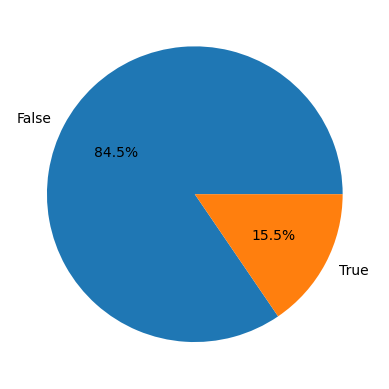

In [45]:
# is classes divided equally?
total=vis_data["Revenue"].value_counts()

plt.pie(
    total,
    labels=["False","True"], # small level first[0,1]
    autopct="%1.1f%%"
)

<Axes: xlabel='Region', ylabel='Count'>

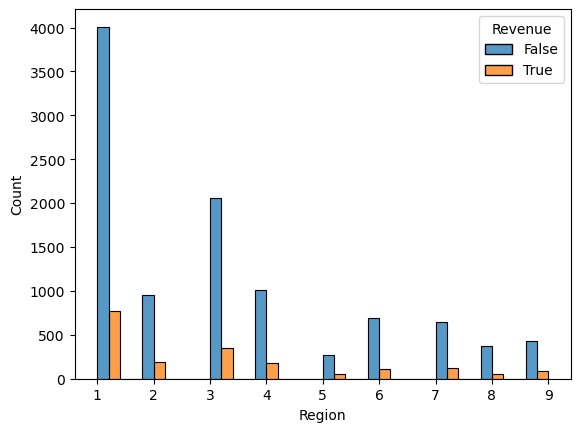

In [46]:
sns.histplot(data=vis_data,x="Region",hue="Revenue",bins=20,multiple="dodge")

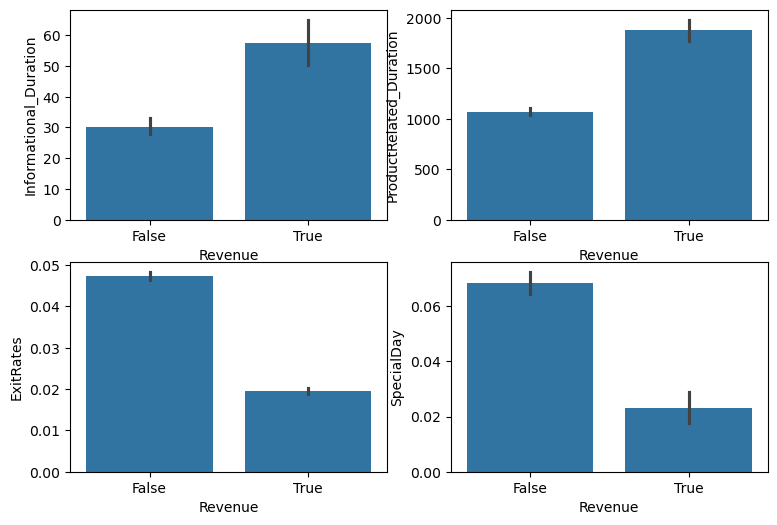

In [47]:
fig,axes=plt.subplots(2,2,figsize=(9,6))

sns.barplot(ax=axes[0,0],data=vis_data,x="Revenue",y="Informational_Duration")
sns.barplot(ax=axes[0,1],data=vis_data,x="Revenue",y="ProductRelated_Duration")
sns.barplot(ax=axes[1,0],data=vis_data,x="Revenue",y="ExitRates")
sns.barplot(ax=axes[1,1],data=vis_data,x="Revenue",y="SpecialDay")

plt.show()

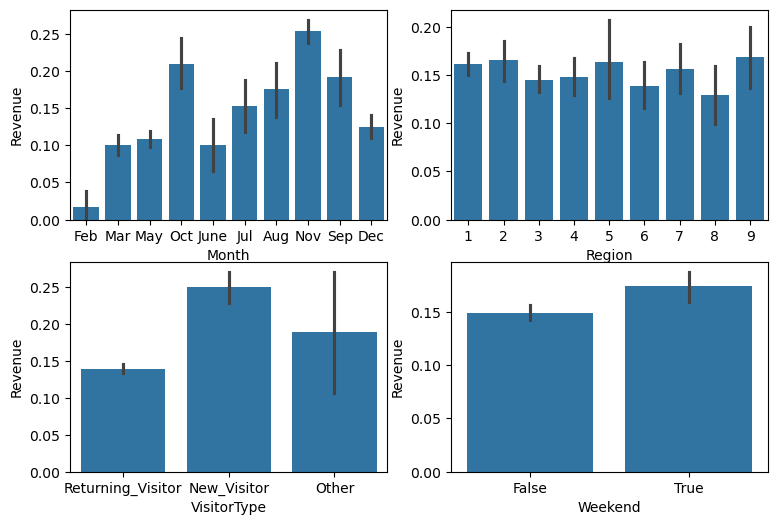

In [48]:
fig,axes=plt.subplots(2,2,figsize=(9,6))

sns.barplot(ax=axes[0,0],data=vis_data,x="Month",y="Revenue")
sns.barplot(ax=axes[0,1],data=vis_data,x="Region",y="Revenue")
sns.barplot(ax=axes[1,0],data=vis_data,x="VisitorType",y="Revenue")
sns.barplot(ax=axes[1,1],data=vis_data,x="Weekend",y="Revenue")

plt.show()

In [49]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
vis_data["Weekend"]=le.fit_transform(vis_data["Weekend"])
vis_data["Revenue"]=le.fit_transform(vis_data["Revenue"])

In [50]:
from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown='ignore')

encode=ohe.fit_transform(vis_data[["VisitorType","Month"]])

In [51]:
encode_op=pd.DataFrame(encode,columns=ohe.get_feature_names_out(["VisitorType","Month"]),index=vis_data.index)

vis_data=pd.concat([vis_data.drop(columns=["VisitorType","Month"]),encode_op],axis=1)

In [52]:
vis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

<Axes: >

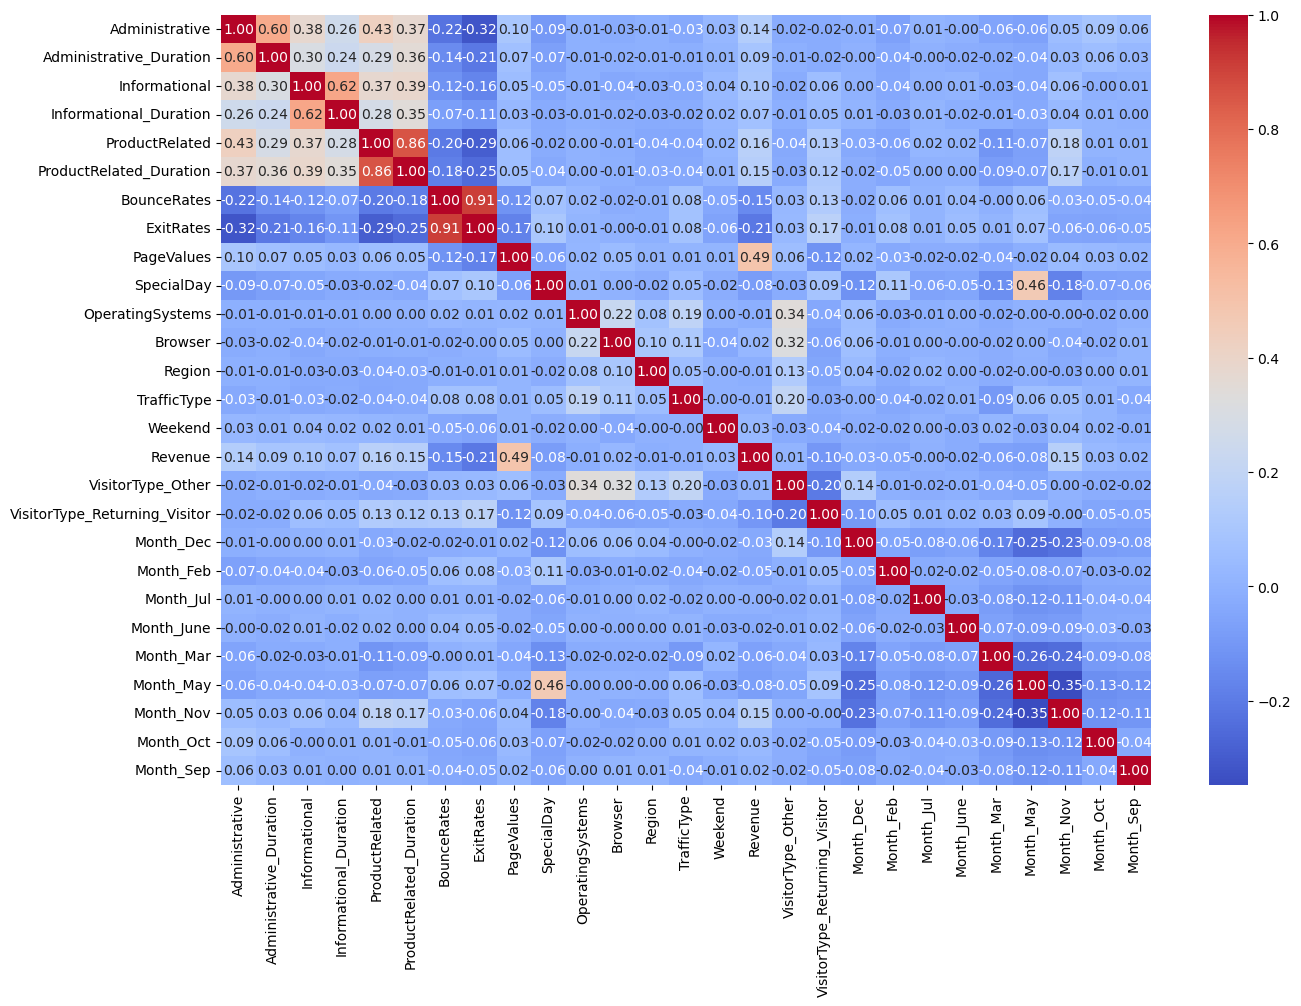

In [53]:
# correlation heatmap

num_cols=vis_data.select_dtypes(include="number")

corr_matrix=num_cols.corr()

plt.figure(figsize=(15,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

In [54]:
vis_data["Page_Values"]=vis_data["PageValues"]**2
vis_data["Exit_Rates"]=vis_data["ExitRates"]**2

In [55]:
vis_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

In [56]:
X=vis_data.drop(columns=["Revenue","PageValues","ExitRates"])
y=vis_data["Revenue"]

In [57]:
 X_train,X_test,y_train,y_test=train_test_split(
     X,y,test_size=0.2,random_state=42
 )

In [58]:
from sklearn.metrics import f1_score,accuracy_score


depths=[2,4,5,6,7,8,9]


for depth in depths:
    model=DecisionTreeClassifier(max_depth=depth,random_state=42)
    model.fit(X_train,y_train)
    
    y_pred=model.predict(X_test)
    print("f1_score:",f1_score(y_test,y_pred),"for depth=",depth)
    print("accuracy_score:",accuracy_score(y_test,y_pred))

    # best_depth=4

f1_score: 0.5256609642301711 for depth= 2
accuracy_score: 0.8763179237631792
f1_score: 0.648 for depth= 4
accuracy_score: 0.8929440389294404
f1_score: 0.5973645680819912 for depth= 5
accuracy_score: 0.8884833738848338
f1_score: 0.6321678321678321 for depth= 6
accuracy_score: 0.8933495539334956
f1_score: 0.6251728907330567 for depth= 7
accuracy_score: 0.8901054339010543
f1_score: 0.6222222222222222 for depth= 8
accuracy_score: 0.8896999188969992
f1_score: 0.6050198150594451 for depth= 9
accuracy_score: 0.8787510137875101


In [59]:
# max_samples_split

sample_splits=[5,10,15,20,25,35,30]


for leaf in sample_splits:
    model=DecisionTreeClassifier(max_depth=4,min_samples_split=split,random_state=42)
    model.fit(X_train,y_train)
    
    y_pred=model.predict(X_test)
    print("f1_score:",f1_score(y_test,y_pred),"for max_sample_split",split)
    print("accuracy_score:",accuracy_score(y_test,y_pred))

# no change

f1_score: 0.648 for max_sample_split 30
accuracy_score: 0.8929440389294404
f1_score: 0.648 for max_sample_split 30
accuracy_score: 0.8929440389294404
f1_score: 0.648 for max_sample_split 30
accuracy_score: 0.8929440389294404
f1_score: 0.648 for max_sample_split 30
accuracy_score: 0.8929440389294404
f1_score: 0.648 for max_sample_split 30
accuracy_score: 0.8929440389294404
f1_score: 0.648 for max_sample_split 30
accuracy_score: 0.8929440389294404
f1_score: 0.648 for max_sample_split 30
accuracy_score: 0.8929440389294404


[Text(0.5, 0.9, 'Page_Values <= 0.983\ngini = 0.257\nsamples = 9864\nvalue = [8367, 1497]\nclass = True'),
 Text(0.25, 0.7, 'Month_Nov <= 0.5\ngini = 0.075\nsamples = 7755\nvalue = [7453, 302]\nclass = True'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Month_Sep <= 0.5\ngini = 0.035\nsamples = 5940\nvalue = [5835, 105]\nclass = True'),
 Text(0.0625, 0.3, 'Page_Values <= 0.006\ngini = 0.029\nsamples = 5684\nvalue = [5601, 83]\nclass = True'),
 Text(0.03125, 0.1, 'gini = 0.027\nsamples = 5650\nvalue = [5573, 77]\nclass = True'),
 Text(0.09375, 0.1, 'gini = 0.291\nsamples = 34\nvalue = [28, 6]\nclass = True'),
 Text(0.1875, 0.3, 'ProductRelated_Duration <= 29.233\ngini = 0.157\nsamples = 256\nvalue = [234, 22]\nclass = True'),
 Text(0.15625, 0.1, 'gini = 0.483\nsamples = 22\nvalue = [13, 9]\nclass = True'),
 Text(0.21875, 0.1, 'gini = 0.105\nsamples = 234\nvalue = [221, 13]\nclass = True'),
 Text(0.375, 0.5, 'ProductRelated_Duration <= 1179.571\ngini = 0.194\nsamples = 1815\nvalue = 

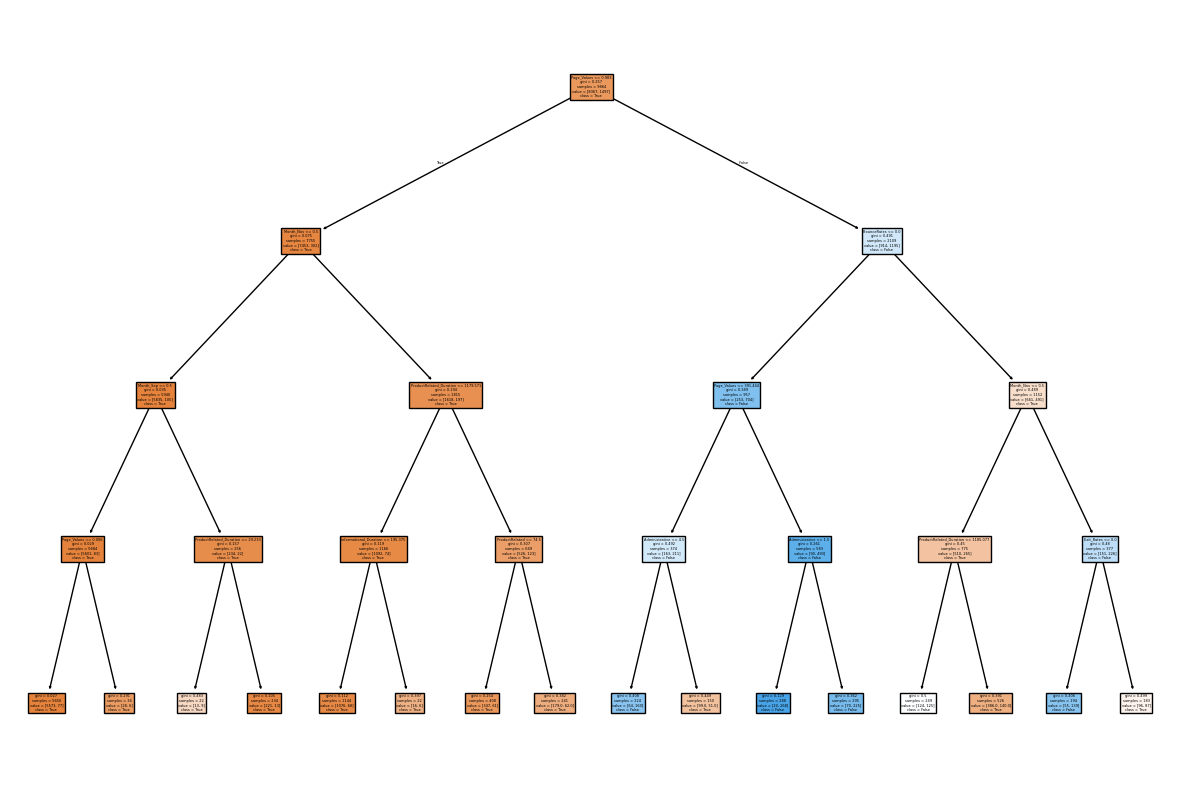

In [60]:
from sklearn.tree import plot_tree

model=DecisionTreeClassifier(max_depth=4,random_state=42)
model.fit(X_train,y_train)
    
y_pred=model.predict(X_test)

plt.figure(figsize=(15,10))
plot_tree(
        model,
        feature_names=X.columns,
        class_names=["True","False"],
        filled=True
)



In [61]:
# post -pruning
model=DecisionTreeClassifier(max_depth=4,random_state=42)
model.fit(X_train,y_train)



path=model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas=path.ccp_alphas

print(ccp_alphas)

[0.         0.00018171 0.00019909 0.00035666 0.00038118 0.0008324
 0.00110976 0.00134332 0.00190601 0.0023272  0.00255183 0.00341065
 0.00365951 0.01014735 0.09360908]


In [66]:
best_alpha=0
best_f1_score=0
curr_score=0

for alpha in ccp_alphas:
    model=DecisionTreeClassifier(max_depth=4,ccp_alpha=alpha,random_state=42)
    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)
    curr_score=f1_score(y_test,y_pred)
   

    if  curr_score>best_f1_score:
        best_f1_score=curr_score
        best_alpha=alpha
        acc=accuracy_score(y_test,y_pred)
        con_matrix=confusion_matrix(y_test,y_pred)

print("best f1 score:",best_f1_score,"for alpha",best_alpha)
print("accuracy_score",acc,"confusion matrix:",con_matrix)

best f1 score: 0.6742502585315409 for alpha 0.01014735484966943
accuracy_score 0.8722627737226277 confusion matrix: [[1825  230]
 [  85  326]]
